##### Hvornår rammer skråt kast cirkel?

Vi ser på et skråt kast der starter i origo, $(x,y)=(0.0)$ med startfart $v=15.0\text{ m/s}$ og en startvinkel $\theta=70.0\degree$.
Vi er interesseret i at plotte det skrå kast sammen med en cirkel og så finde det sted og den tid som det skrå kast rammer cirklen med centrum i $(15,0)$ og radius $5.0$.

Vi starter med at importere *numpy* der står for *numerical python* og indeholder data typer og metoder der effektivt kan regne på data i vektorer (og lign.).


In [17]:
import numpy as np

Dernæst definerer vi nogle af de værdier der har med det skrå kast at gøre, startfart, startvinkel og tyngdeaccelerationen.

In [18]:
v = 15.0
theta = np.deg2rad(70.0)
g = 9.82

Så beregner vi selv banen for det skrå kast.

Først vælger vi de tidspunkter som vi vil have positionen til.
Vi laver en vektor (array) med 1000 punkter fra 0 til 3 sekunder.

Dernæst bergner vi positionen hvor vi benytter at *numpy* kan regne på mange tal på en gang, her beregner den for alle 1000 værdier af tiden på en gang.
Det vil sige at x og y er vektorer med 1000 elementer.

In [ ]:
t = np.linspace(0,3,1000) # laver en vektor med 1000 punkter fra 0 til 3 sekunder
x = v * np.cos(theta) * t
y = v * np.sin(theta) * t - 1/2 * g * t**2

Vi plotter nu data med *matplotlib* pakken.

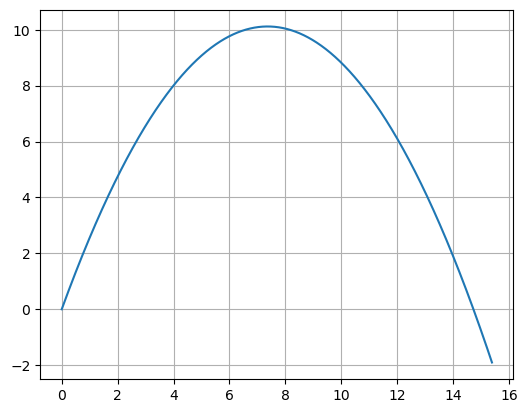

In [20]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(x,y)
plt.grid()
plt.axis('scaled')
plt.show()

Vi ser at vi får negtive værdier af y, det var ikke meningen.
Vi kan udvælge de data vi gerne vil have ved at opstille et logisk udtryk der svarer til de punkter vi gerne vil have, her er det
at y ikke er negativ. Man konstruerer en maske der indeholder True eller False, når man benytter den returnerer den kun værdier ved True.
Vi anvender det på t, x og y og plotter igen, nu med det ønskede resultat.

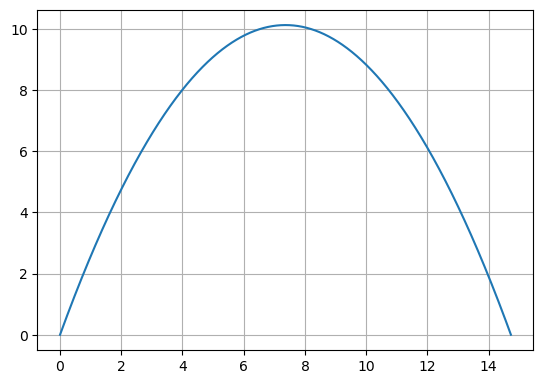

In [21]:
mask = y >= 0
t = t[mask]
x = x[mask]
y = y[mask]
plt.figure()
plt.plot(x,y)
plt.grid()
plt.axis('scaled')
plt.show()

Så tegner vi også cirklen. Det gør vi ved at beregne punkterne på cirklen (det kan gøre på andre måder) og da vi ved at vi ikke er interesseret i 
negative værdier lave vi også her en maske der fjerner de uønskede punkter.

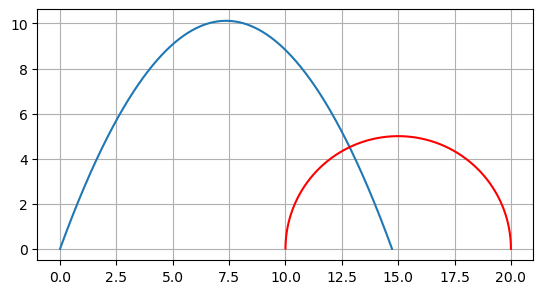

In [ ]:
T = np.linspace(0,2*np.pi,1000) # laver en vektor med 1000 punkter fra 0 til 2*pi der skal bruges til at tegne cirklen
x0 = 15.0
y0 = 0.0
r = 5.0
X = r * np.cos(T) + x0
Y = r * np.sin(T) + y0
mask = Y >= 0 # sorterer punkter under jorden fra
X = X[mask]
Y = Y[mask]
plt.figure()
plt.plot(x,y)
plt.plot(X,Y,'r-')
plt.grid()
plt.axis('scaled')
plt.show()


For at bestemme hvor banen rammer cirklen beregner vi for alle punkterne $(x,y)$ størrelsen $(x-x_0)^2+(y-y_0)^2-r^2$
hvor $(x_0,y_0)$ er cirklens centrum og $r$ er dens radius.
Hvis den beregnede størrelse er ikke-negativ er punktet udenfor cirklen. Vi sorterer nu alle punkter indenfor cirklen fra.
Metoden *dst* beregner størrelsen $(x-x_0)^2+(y-y_0)^2-r^2$ for alle punkter.
Vi sorterer dernæst punkter fra og plotter igen.

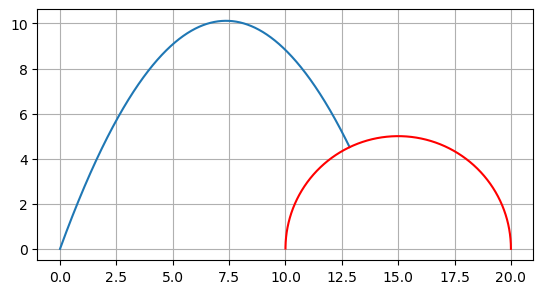

In [ ]:
def dst(x,y):
    return (x-x0)**2 + (y-y0)**2 - r**2
d = dst(x,y)
mask = d >= 0 # sorterer punkter udenfor cirklen fra
t = t[mask]
x = x[mask]
y = y[mask]
plt.figure()
plt.plot(x,y)
plt.plot(X,Y,'r-')
plt.grid()
plt.axis('scaled')
plt.show()

Vi kan nu finde tid og sted for hvor banen rammer cirklen, det er de sidste punkter i t, x og y som vi finder ved at indicere med -1. 

In [ ]:
print(t[-1],x[-1],y[-1])
print('t = {:.2f} s, x = {:.2f} m, y = {:.2f} m'.format(t[-1],x[-1],y[-1]))

2.5034503450345036 12.843456687260941 4.51484281243081
t = 2.50 s, x = 12.84 m, y = 4.51 m
0.034484680677703494


Vi plotter det endnu engang med et mærke hvor der rammes.

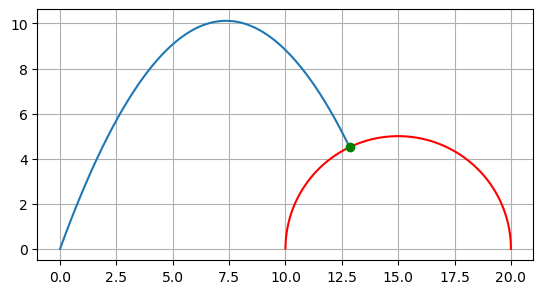

In [25]:
plt.figure()
plt.plot(x,y)
plt.plot(X,Y,'r-')
plt.plot(x[-1],y[-1],'go')
plt.grid()
plt.axis('scaled')
plt.show()